# Stat - Data Visualization

This notebook demonstrates the high-level plotting capabilities of the `stat` library.
The `.plot()` method is designed to be "smart"—it automatically chooses the most appropriate plot based on the data types and number of columns provided, while allowing full manual control.

---

## 1. Setup

We will use the `insurance` dataset to explore various visualization techniques.

In [1]:
import pandas as pd
import src.stat as stat

# Load data
pd_df = pd.read_csv('../examples/assets/insurance.csv')
df = stat.represent(pd_df)
df.show('Insurance Dataset', max_rows=5)

                               Insurance Dataset                               
+-----------------------------------------------------------------------------+
| Index | age | sex    | bmi    | children | smoker | region    | charges     |
|-------+-----+--------+--------+----------+--------+-----------+-------------|
|     0 | 19  | female | 27.9   | 0        | yes    | southwest | 16884.924   |
|     1 | 18  | male   | 33.77  | 1        | no     | southeast | 1725.5523   |
|     2 | 28  | male   | 33.0   | 3        | no     | southeast | 4449.462    |
|     3 | 33  | male   | 22.705 | 0        | no     | northwest | 21984.47061 |
|     4 | 32  | male   | 28.88  | 0        | no     | northwest | 3866.8552   |
|   ... | ... | ...    | ...    | ...      | ...    | ...       | ...         |
+-----------------------------------------------------------------------------+

## 2. Automatic Plot Detection

By default, calling `.plot()` with specific columns will infer the best visualization.

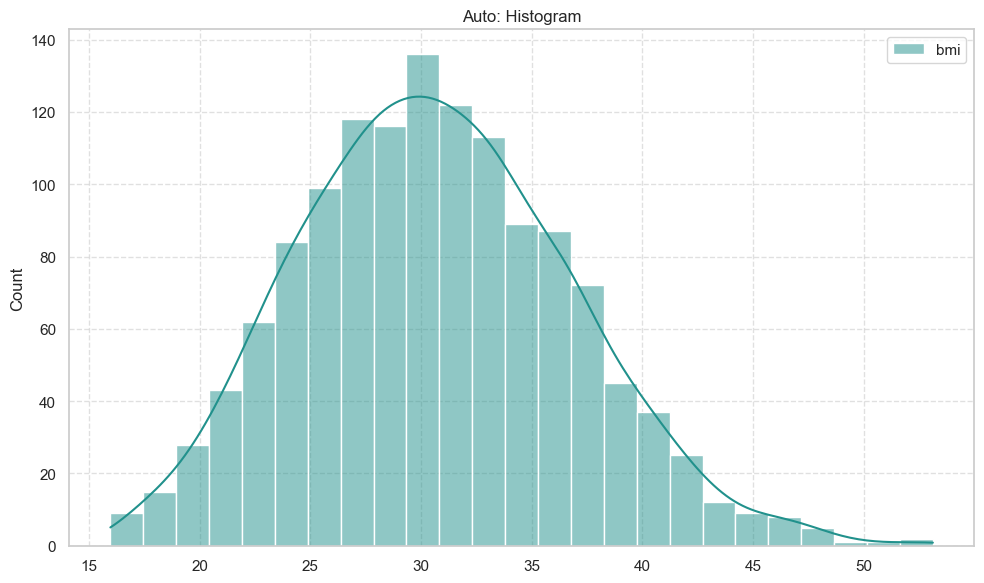

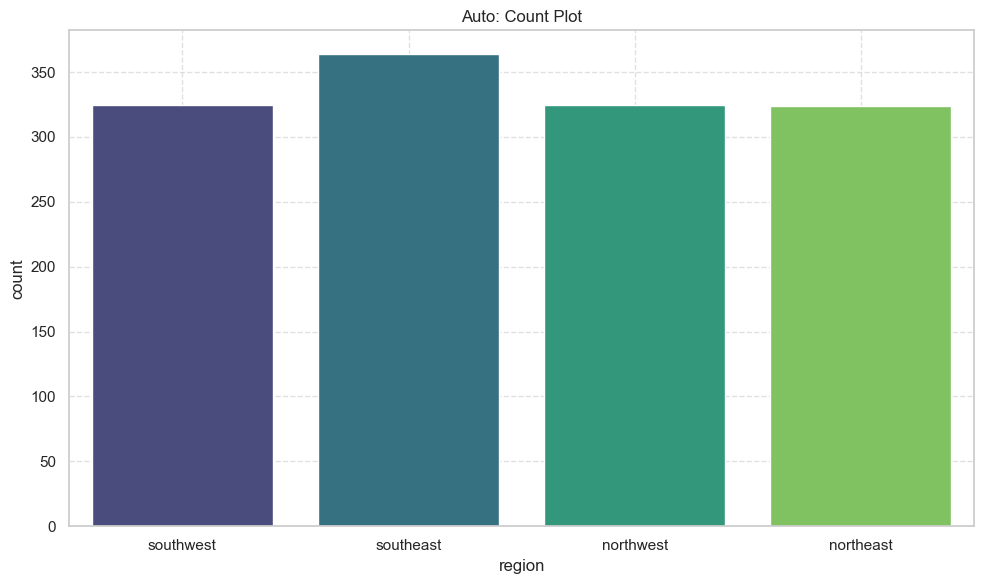

C:\Users\aarin\PycharmProjects\Stat\src\stat\graphs\plotter.py:69: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax, **kwargs)


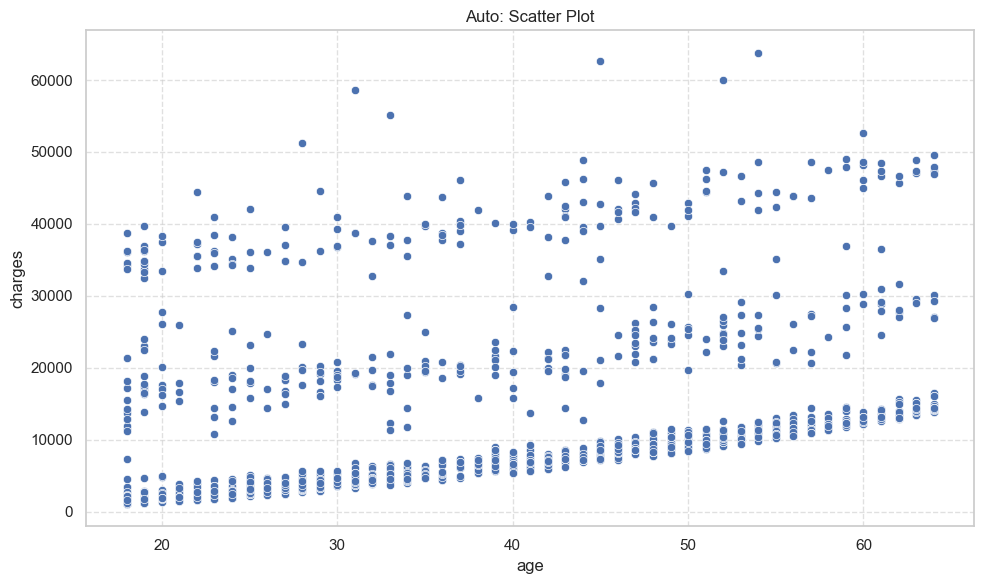

In [2]:
# 1 Numeric Column -> Histogram with KDE
df.plot(columns='bmi', title='Auto: Histogram')

# 1 Categorical Column -> Count Plot
df.plot(columns='region', title='Auto: Count Plot')

# 2 Numeric Columns -> Scatter Plot
df.plot(columns=['age', 'charges'], title='Auto: Scatter Plot')

## 3. Explicit Plot Types

You can manually set the `kind` parameter to force a specific style.

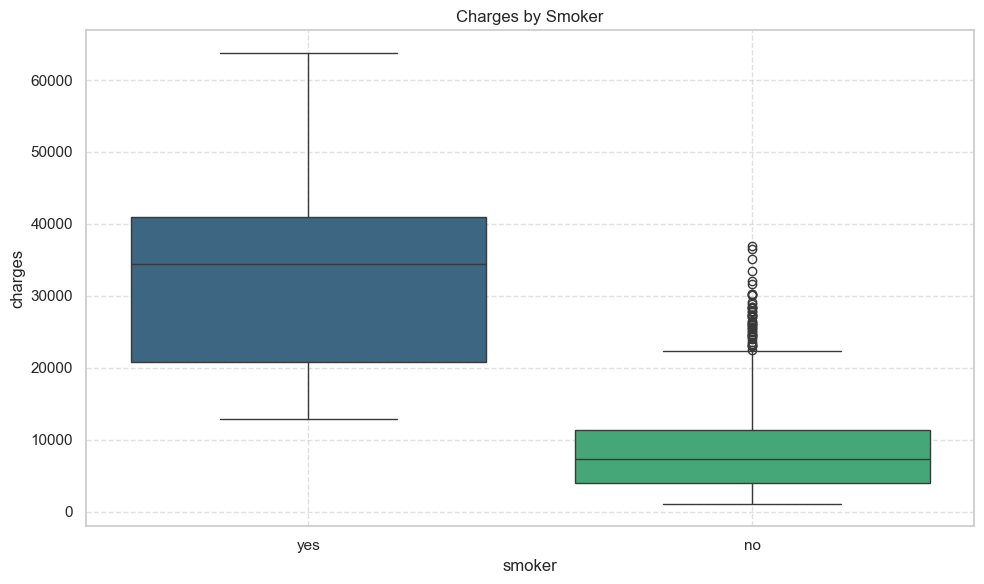

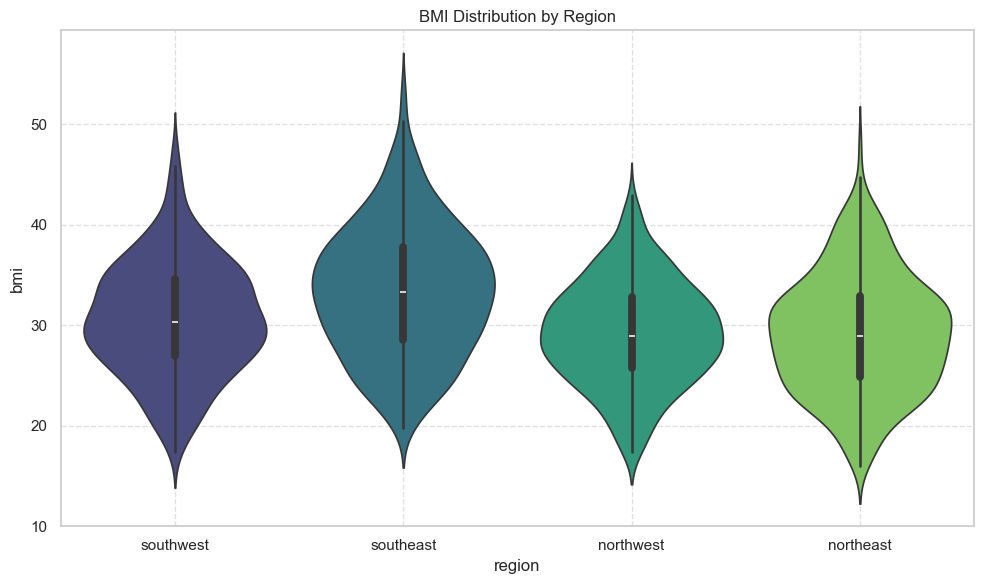

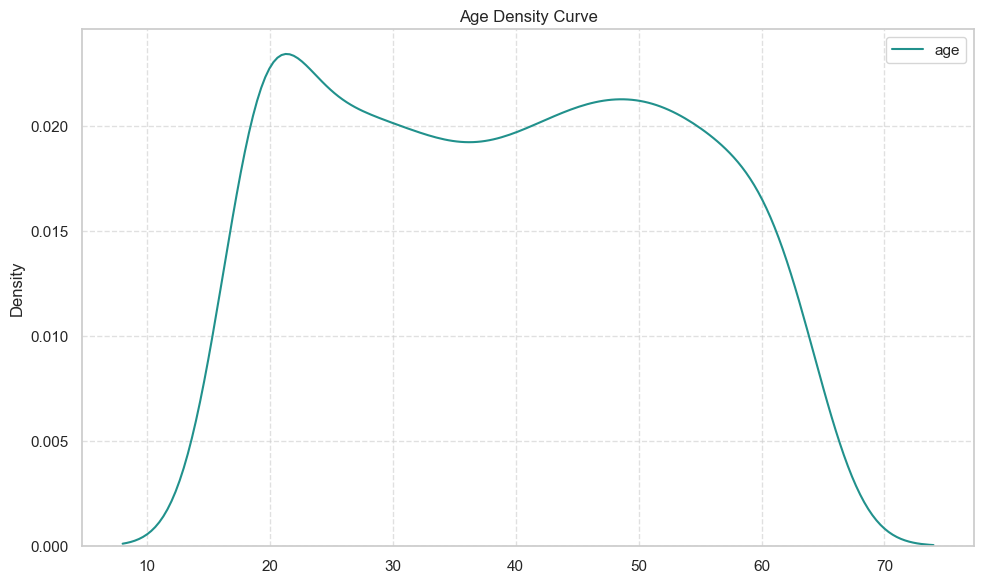

In [3]:
# Box Plot: Compare Charges by Smoker status
df.plot(columns=['smoker', 'charges'], kind='box', title='Charges by Smoker')

# Violin Plot: Compare BMI by Region
df.plot(columns=['region', 'bmi'], kind='violin', title='BMI Distribution by Region')

# KDE Plot: Smooth density of Age
df.plot(columns='age', kind='kde', title='Age Density Curve')

## 4. Theming and Aesthetics

The library supports several built-in themes to change the visual look instantly.

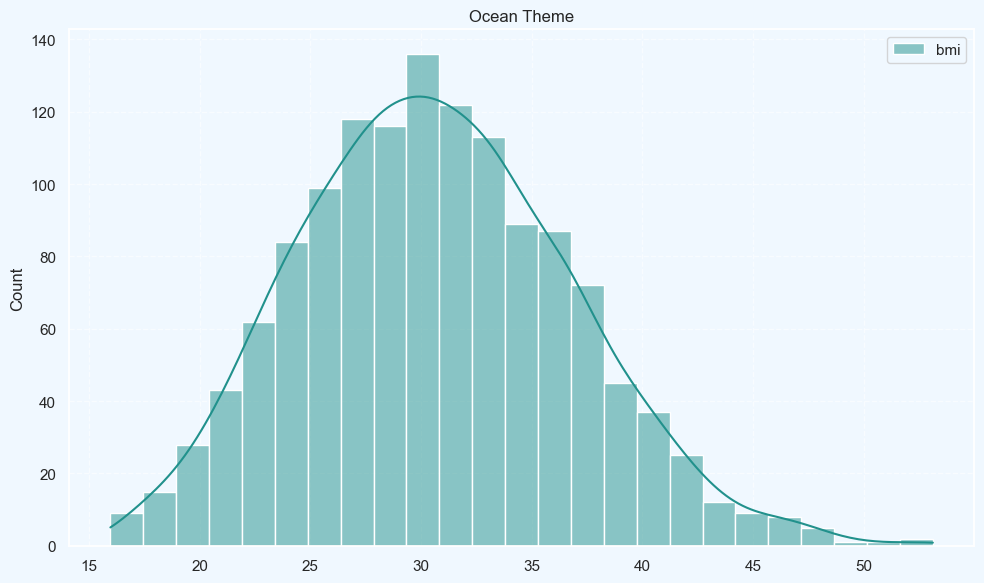

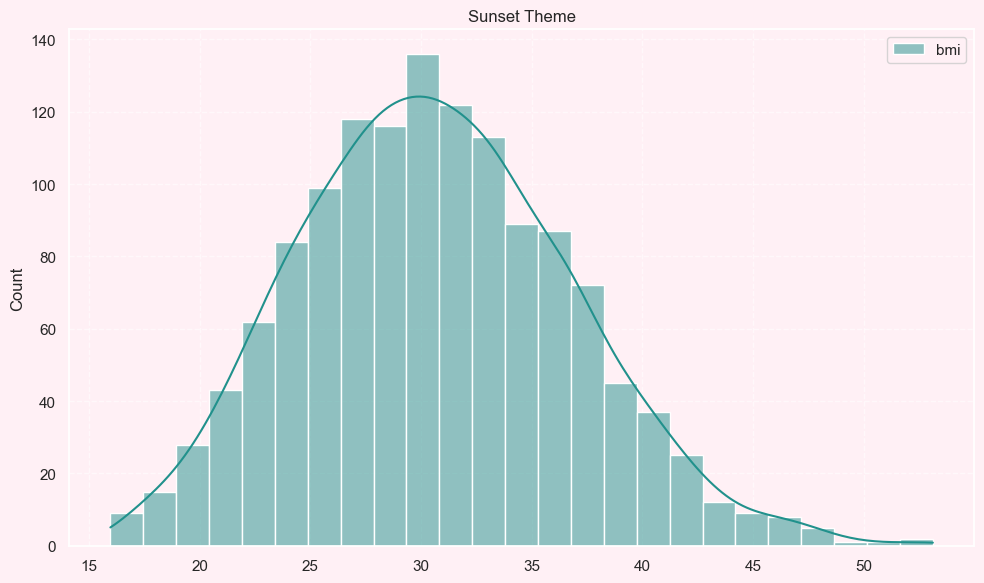

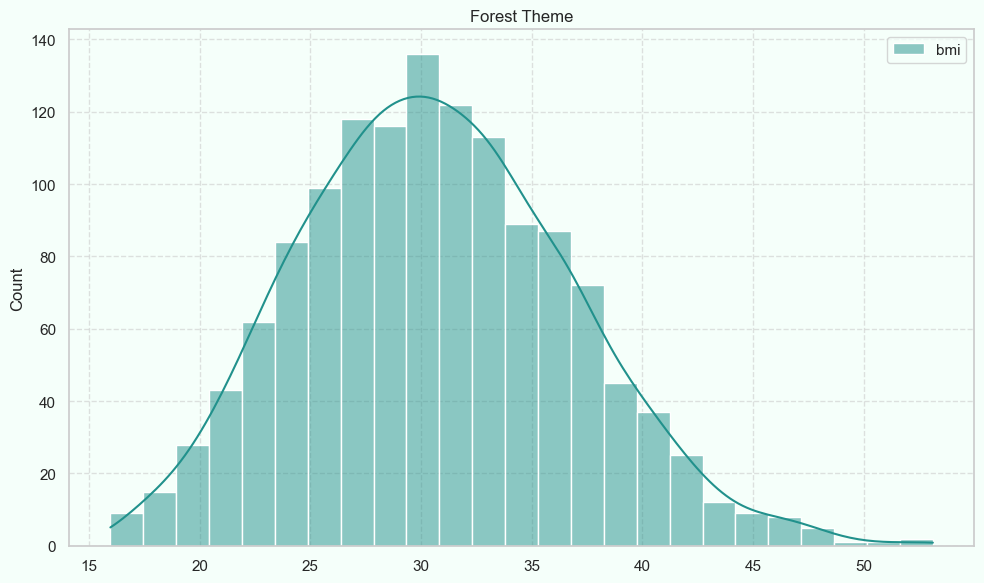

In [4]:
# 'ocean' theme
df.plot(columns='bmi', theme='ocean', title='Ocean Theme')

# 'sunset' theme
df.plot(columns='bmi', theme='sunset', title='Sunset Theme')

# 'forest' theme
df.plot(columns='bmi', theme='forest', title='Forest Theme')

## 5. Advanced Features: Hue and Palette

Since the library is powered by `Seaborn`, you can pass standard kwargs like `hue` to add another dimension of data.

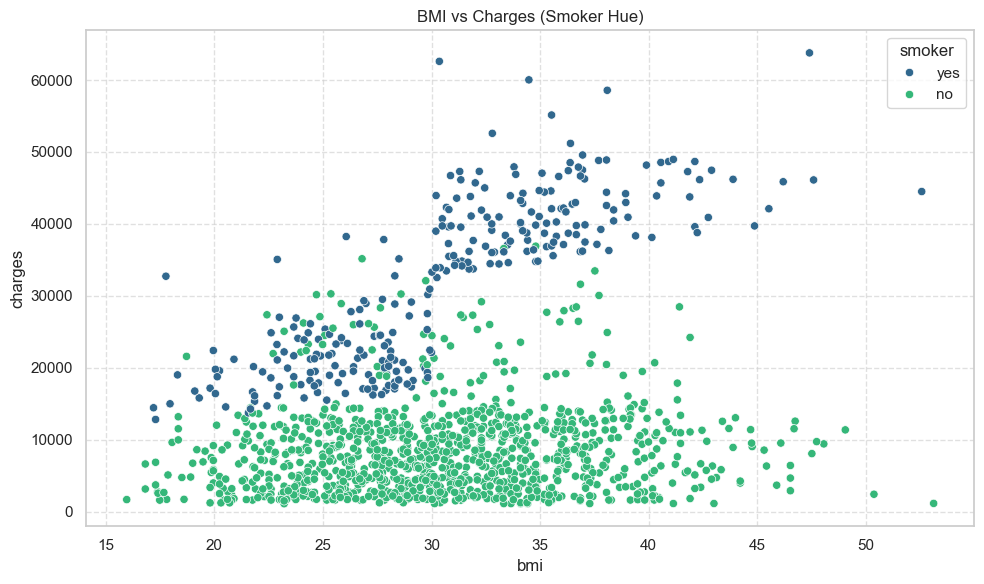

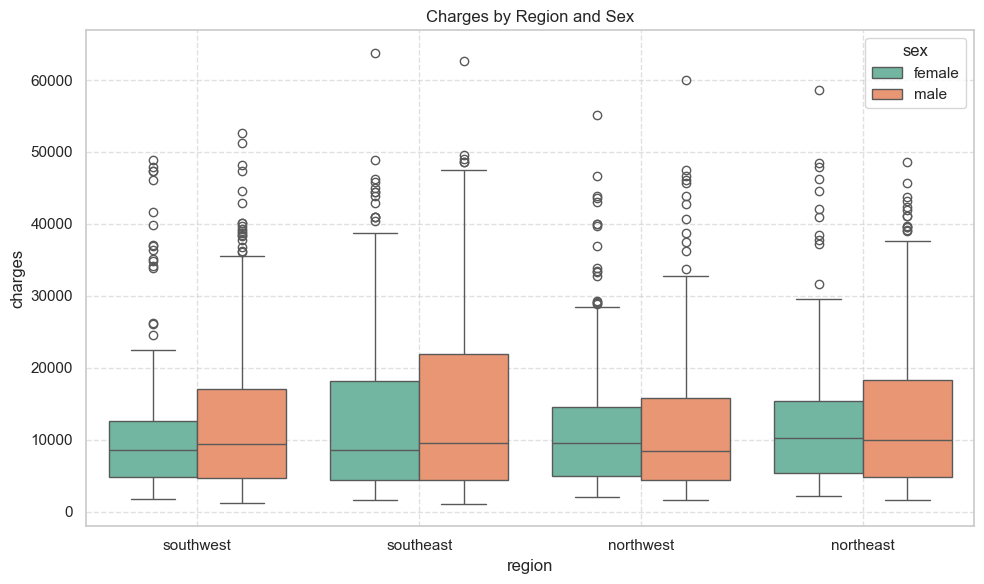

In [2]:
# Scatter plot with Smoker status as color
df.plot(columns=['bmi', 'charges'], kind='scatter', hue='smoker', title='BMI vs Charges (Smoker Hue)')

# Box plot with Sex as color
df.plot(columns=['region', 'charges'], kind='box', hue='sex', palette='Set2', title='Charges by Region and Sex')

## 6. Correlation Heatmaps

One of the most useful features for understanding relationships across a whole DataFrame.

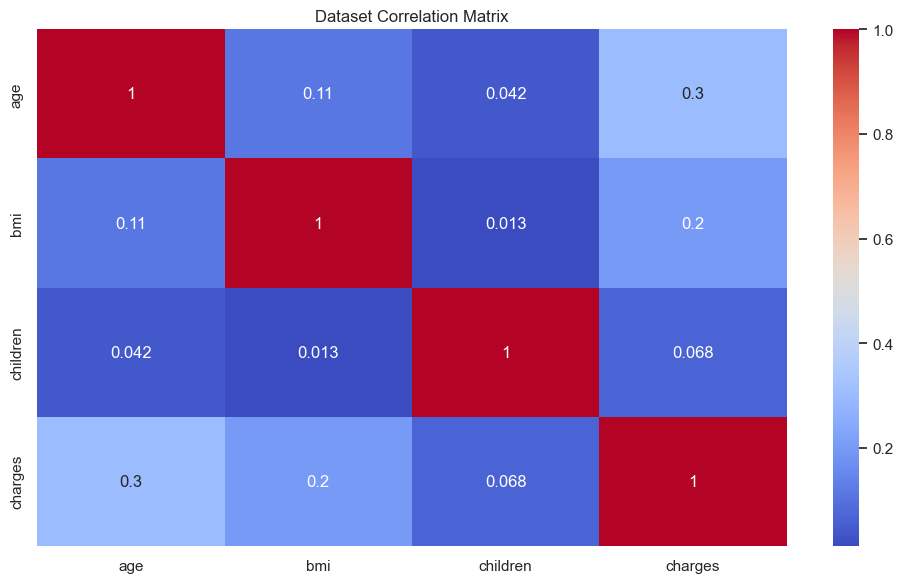

In [6]:
# Filter to numeric only and plot heatmap
df.filter_types('n').plot(kind='heatmap', title='Dataset Correlation Matrix')

## 7. 1D Array Plotting

The `.plot()` method also works seamlessly on simple lists or numpy-based Stat objects.

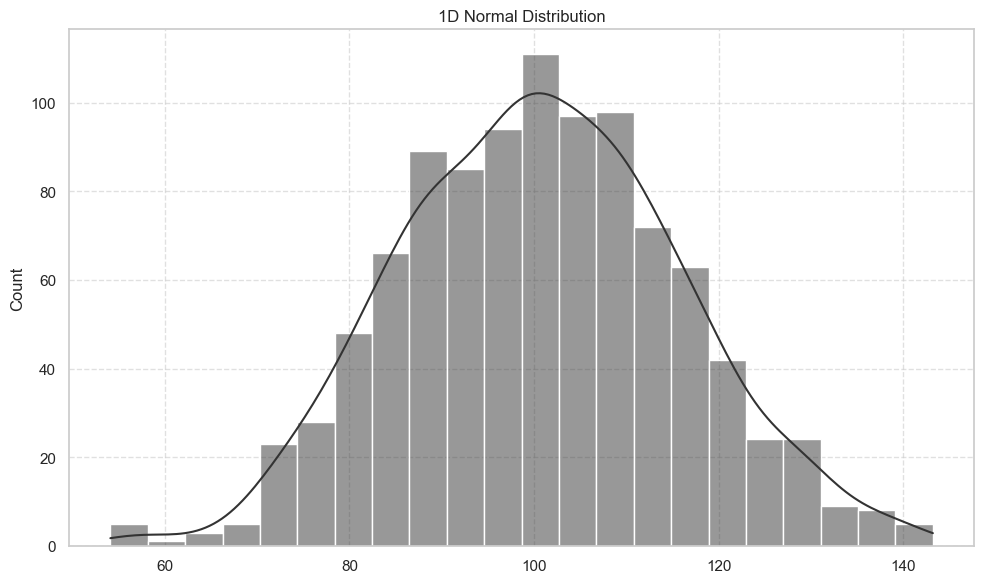

In [8]:
import numpy as np
simple_data = stat.represent(np.random.normal(100, 15, 1000))
simple_data.plot(kind='hist', title='1D Normal Distribution')